# **DATASET: Pittsburgh Parks**

**Description:** A list of city parks and which neighbord they reside in <br>
**Metric:** Greater number of parks = better neighborhood. More parks in a neighborhood allow people to get fresh air, exercise, and enjoy extracurricular activities (i.e. sports). This contributes to healthy residents both physically and mentally.

In [1]:
import pandas as pd

In [2]:
parksData = pd.read_csv('https://data.wprdc.org/datastore/dump/fa329e3d-89ff-4708-8ddf-81bfedcad11d')
pd.set_option('display.max_rows', 30)

In [3]:
parksData.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 209 entries, 0 to 208
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   _id                         209 non-null    int64  
 1   id                          209 non-null    int64  
 2   name                        209 non-null    object 
 3   type                        209 non-null    object 
 4   maintenance_responsibility  209 non-null    object 
 5   image                       63 non-null     object 
 6   neighborhood                209 non-null    object 
 7   council_district            209 non-null    int64  
 8   ward                        209 non-null    int64  
 9   tract                       209 non-null    int64  
 10  public_works_division       209 non-null    int64  
 11  pli_division                209 non-null    int64  
 12  police_zone                 209 non-null    int64  
 13  fire_zone                   209 non

In [4]:
parksData.columns

Index(['_id', 'id', 'name', 'type', 'maintenance_responsibility', 'image',
       'neighborhood', 'council_district', 'ward', 'tract',
       'public_works_division', 'pli_division', 'police_zone', 'fire_zone',
       'latitude', 'longitude'],
      dtype='object')

In [5]:
parksData

,_id,id,name,type,maintenance_responsibility,image,neighborhood,council_district,ward,tract,public_works_division,pli_division,police_zone,fire_zone,latitude,longitude
0,1,2111959181,Able Long Park,Park,Parks - Southern,https://tools.wprdc.org/images/pittsburgh/park...,Beechview,4,19,42003192000,5,19,6,4-28,40.408118,-80.028197
1,2,1109513049,Albert Turk Graham Park,Park,Parks - Schenley,https://tools.wprdc.org/images/pittsburgh/park...,Crawford-Roberts,6,3,42003030500,3,3,2,2-1,40.440507,-79.984018
2,3,1544096765,Alcoa Park,Park,Parks - Northern,NaN,North Shore,1,22,42003563200,6,22,1,1-20,40.447481,-80.001017
3,4,1212681573,Allegheny Commons,Park,Parks - Northern,NaN,Allegheny Center,1,22,42003562700,1,22,1,1-7,40.453126,-80.009158
4,5,954863286,Allegheny Landing Park,Park,Parks - Northern,NaN,North Shore,1,22,42003563200,6,22,1,1-20,40.447184,-80.002907
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
204,205,1460363095,Woods Run Park,Park,Parks - Northern,https://tools.wprdc.org/images/pittsburgh/park...,Marshall-Shadeland,1,27,42003271500,1,27,1,1-14,40.476383,-80.029253
205,206,930068146,Young Field Park,Park,Parks - Northern,NaN,Marshall-Shadeland,1,27,42003271500,1,27,1,1-14,40.472963,-80.032768
206,207,1127012019,Zulema Park,Park,Parks - Schenley,NaN,Central Oakland,3,4,42003040500,3,4,4,2-14,40.435693,-79.957048
207,208,1719897212,Liberty Green Park,Park,Parks - Northeast,NaN,East Liberty,9,11,42003111500,2,11,5,3-10,40.462773,-79.919314


## **Columns to Remove**

In [6]:
parksData['type'].unique()

array(['Park', 'Traffic Island/Median', 'Building Grounds',
       'Monument/Memorial', 'Open Space'], dtype=object)

In [7]:
removeColumns = ['_id', 'id', 'maintenance_responsibility', 'image', 'council_district', 'ward', 'tract', 'public_works_division', 'pli_division', 'police_zone', 'fire_zone', 'latitude', 'longitude']
parksData.drop(columns = removeColumns, inplace = True)

## **Count of Parks, Traffic Island/Medians, Building Grounds, Monument/Memorials, and Open Space Within Each Neighborhood.**

In [8]:
(parksData
    .assign(total = parksData.groupby('neighborhood')['type'].transform('count'),
            count = parksData.groupby(['neighborhood', 'type'])['type'].transform('count'))   
    .drop_duplicates(subset = ['type', 'neighborhood'])
    .sort_values(by = ['total', 'neighborhood', 'count'], ascending = (False, True, False))
    .set_index(['neighborhood', 'type'])
    [['name', 'count', 'total']]
)

name  \
neighborhood              type                                               
East Liberty              Traffic Island/Median             Amber Triangle   
                          Park                           East Liberty Park   
Central Business District Traffic Island/Median              Bedford Strip   
                          Park                   Allegheny Riverfront Park   
                          Open Space                    Market Square Park   
...                                                                    ...   
Squirrel Hill North       Park                               Wightman Park   
Stanton Heights           Park                                  Dinan Park   
Upper Hill                Park                     Robert E. Williams Park   
West Oakland              Park                    Shalane's Play Yard Park   
Windgap                   Park                              Chartiers Park   

                                                 count  total  
neighborhood              type                                 
East Liberty              Traffic Island/Median      8     12  
                          Park                       4     12  
Central Business District Traffic Island/Median      5     10  
                          Park                       3     10  
                          Open Space                 2     10  
...                                                ...    ...  
Squirrel Hill North       Park                       1      1  
Stanton Heights           Park                       1      1  
Upper Hill                Park                       1      1  
West Oakland              Park                       1      1  
Windgap                   Park                       1      1  

[104 rows x 3 columns]

## **Remove Non-Park Types**

The reason I am removing every type but the parks is because oftentimes the other types (e.g. monument, memorials, traffic island, medians, open space, and building grounds) are not good representations of parks.
* Traffic islands/medians are not resembalance of parks
* Monuments are not resembalance of parks
* Building grounds often included buildings such as nursing homes or other activity centers
* Open spaces often included plazas (no grass), small get-together spots, etc. Not close enough to the 'parks' type

## **Count and Name of Parks**

In [10]:
(parksData
    .query('type == "Park"')  
    .assign(count = lambda df: df.groupby('neighborhood')['type'].transform('count'))
    .set_index(['neighborhood', 'name'])
    .sort_values(by = ['count', 'neighborhood', 'name'], ascending = (False, True, True))
    [['type', 'count']]
)

type  count
neighborhood   name                                                    
Beechview      Able Long Park                               Park      6
               Alton Park                                   Park      6
               Beechview Healthy Active Living Center Park  Park      6
               Pauline Park                                 Park      6
               Tropical Park                                Park      6
...                                                          ...    ...
Swisshelm Park Swisshelm Park                               Park      1
Upper Hill     Robert E. Williams Park                      Park      1
West End       Wabash Park                                  Park      1
West Oakland   Shalane's Play Yard Park                     Park      1
Windgap        Chartiers Park                               Park      1

[153 rows x 2 columns]

## **Final Parks DataFrame**

In [11]:
parksFinal = parksData

In [12]:
parksFinal =( parksFinal
            .query('type == "Park"')  
            .assign(count = lambda df: df.groupby('neighborhood')['type'].transform('count'))
            .set_index(['neighborhood', 'name'])
            .sort_values(by = ['count', 'neighborhood', 'name'], ascending = (False, True, True))
            [['type', 'count']]
            )
parksFinal.head(50)

type  count
neighborhood     name                                                    
Beechview        Able Long Park                               Park      6
                 Alton Park                                   Park      6
                 Beechview Healthy Active Living Center Park  Park      6
                 Pauline Park                                 Park      6
                 Tropical Park                                Park      6
...                                                            ...    ...
Beltzhoover      Warrington Park                              Park      3
Bloomfield       Friendship Park                              Park      3
                 Morrow Triangle Park                         Park      3
                 Osceola Park                                 Park      3
Brighton Heights Brighton Heights Park                        Park      3

[50 rows x 2 columns]

## **Graph of All Neighborhoods**

<Axes: ylabel='neighborhood'>

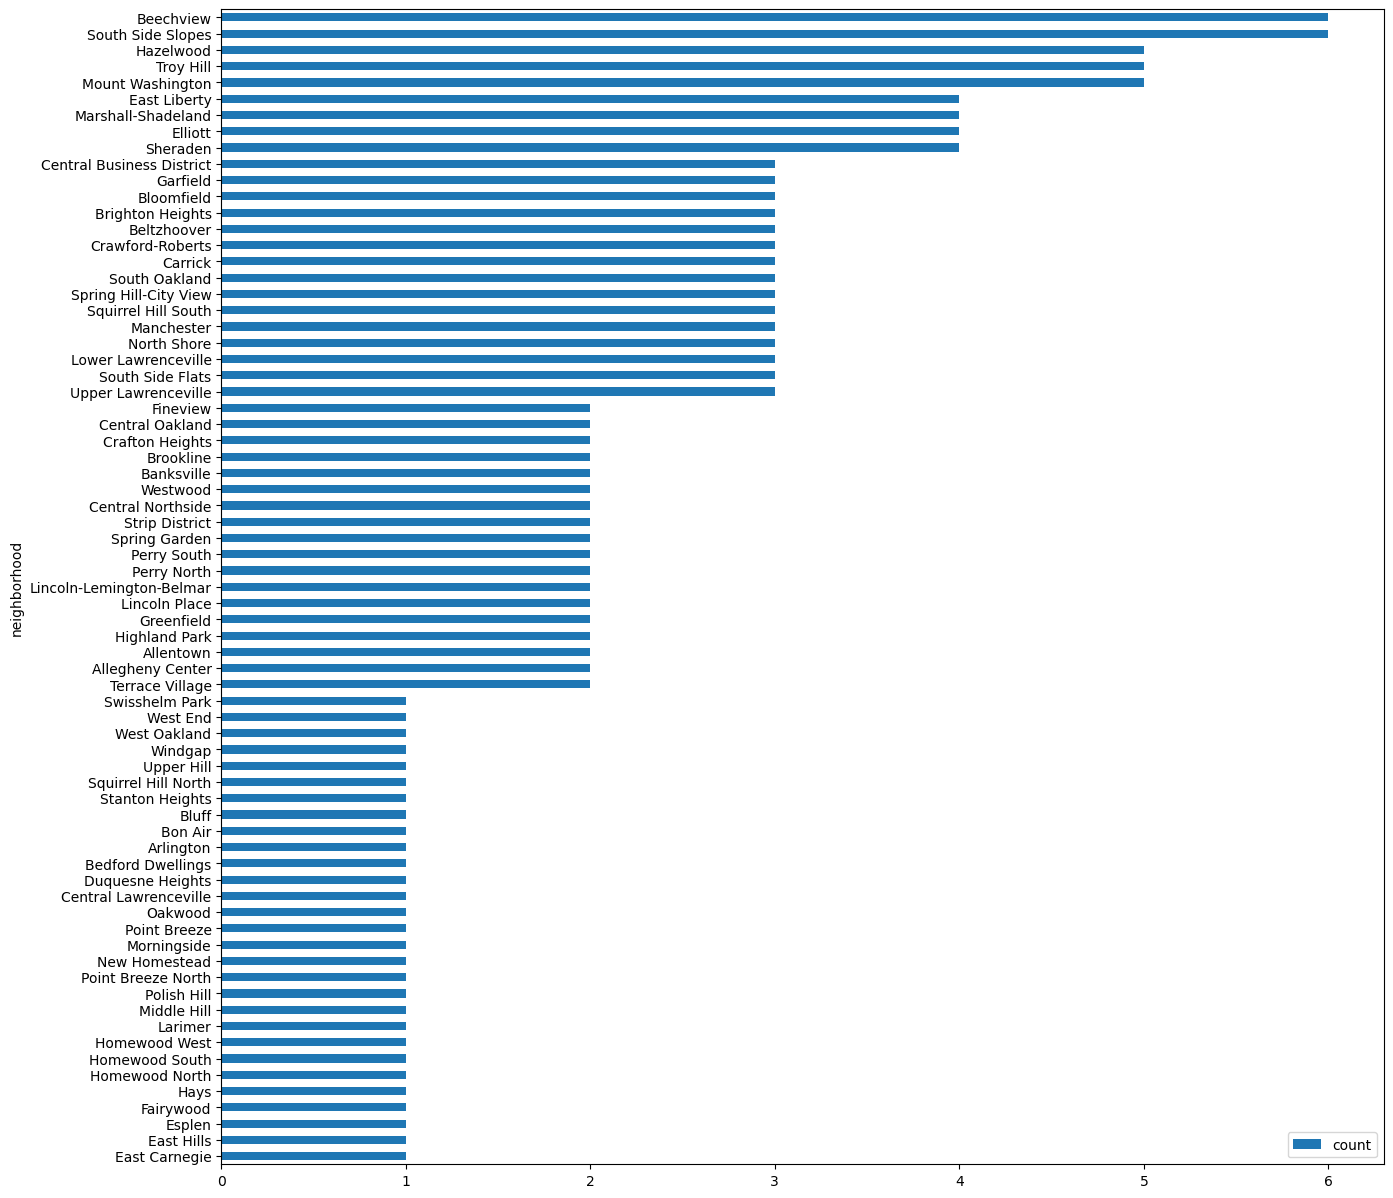

In [22]:
(
    parksFinal
        .reset_index()
        .drop_duplicates(subset = 'neighborhood')
        .set_index('neighborhood')
        .drop(columns = ['name', 'type'])
        .sort_values(by = 'count')
        .plot.barh(figsize = (15,15))
    
)

## **Graph of Best 5 Neighborhoods**

<Axes: ylabel='neighborhood'>

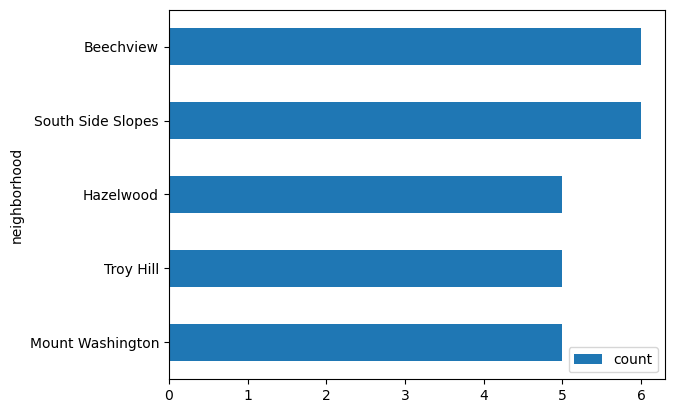

In [30]:
(
    parksFinal
        .reset_index()
        .drop_duplicates(subset = 'neighborhood')
        .set_index('neighborhood')
        .drop(columns = ['name', 'type'])
        .sort_values(by = 'count')
        .tail()
        .plot.barh()
    
)

## **Graph of Worst 5 Neighborhoods**

<Axes: ylabel='neighborhood'>

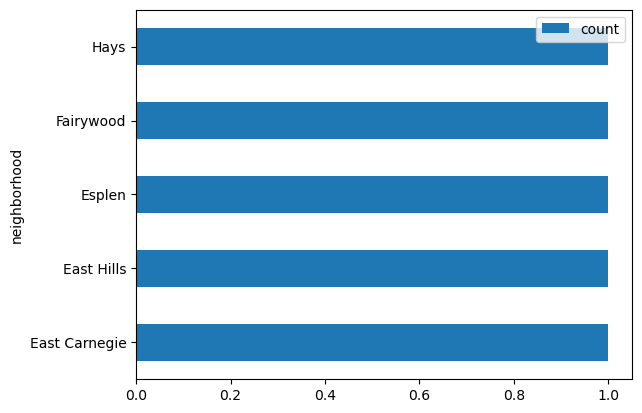

In [31]:
(
    parksFinal
        .reset_index()
        .drop_duplicates(subset = 'neighborhood')
        .set_index('neighborhood')
        .drop(columns = ['name', 'type'])
        .sort_values(by = 'count')
        .head()
        .plot.barh()
    
)

## **Conclusion**

Using a dataset containing the neighborhood parks in Pittsburgh, I concluded that Beechview and South Side Slopes is the best neighborhood based on the sheer number of parks. To come to this conclusion I removed unneccesary columns, removed irrelevant "types", combined neighborhoods based on cardinal directions, and counted the number of parks within each neighborhood. Beechview and South Side Slopes had the most at 6, followed by Hazelwood, Troy Hill, and Mount Washington at 5.

I was pretty suprised that South Side Slopes came out on top because I expected it to be much lower. I would have guessed Squirrel Hill as the number one spot because it includes two of the largest parks in Pittsburgh, Frick and Schenley. The reason it did not appear in the top 5 is due to the datasets lack of any acreage metric. Incorporating an acreage metric would drastically change the results, most likely making my favorite neighborhood, Squirrel Hill, number one.